# Sample Analysis

### By Hannah Mills

## Introduction

For my 2026 Winter Term class, we had to do an individual project using a dataset to create interesting data visualizations and learning something new. I chose to take a movie dataset, and use plotly and a shiny dashboard to analyze movies that pass what is known as the Bechdel test. Most importantly, disproving the fact that films containing significant female leads or characters tend to perform worse at a box office, or generate a lower ROI. 

For this sample analysis, I chose to expand on this by implementing machine learning techniques to predict whether a movie will or will not pass this test based on a series of features. 

In [2]:
# Load packages

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Load dataset

movies_raw = pd.read_csv('movies.csv')

#Drop uneeded columns

cols_to_drop = ['imdb', 'title', 'test', 'clean_test', 'code', 'imdb_id', 'response', 'poster', 'type', 'plot', 'awards', 'error', 'period_code', 'decade_code', 'actors', 'director',
'budget', 'domgross', 'intgross', 'actors', 'writer', 'released']

movies_clean = movies_raw.drop(columns=cols_to_drop)

# Handle missing values - drop them. We have enough rows. Should not impute these

movies_clean = movies_clean.dropna(subset=['imdb_rating', 'genre', 'runtime'])

# Clean runtime column by dropping min and imdb_votes by removing comma

movies_clean['runtime'] = movies_clean['runtime'].str.extract('(\d+)').astype(int)
movies_clean['imdb_votes'] = movies_clean['imdb_votes'].str.replace(',', '').astype(float)

# Map PASS to 1 and FAIL to 0 

movies_clean['target'] = movies_clean['binary'].map({'PASS': 1, 'FAIL': 0})

<positron-console-cell-3>:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


# Exploratory Data Analysis (EDA)

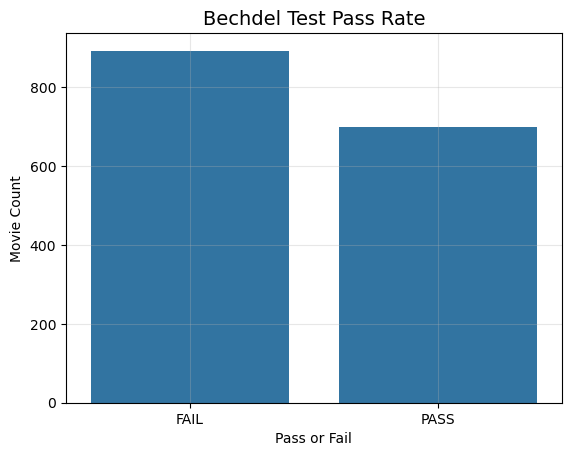

In [21]:
sns.countplot(data=movies_clean, x='binary')
plt.title('Bechdel Test Pass Rate', fontsize=14)
plt.ylabel('Movie Count')
plt.xlabel('Pass or Fail')
plt.grid(alpha=0.3)

# how to rename 0 and 1 to pass versus fail

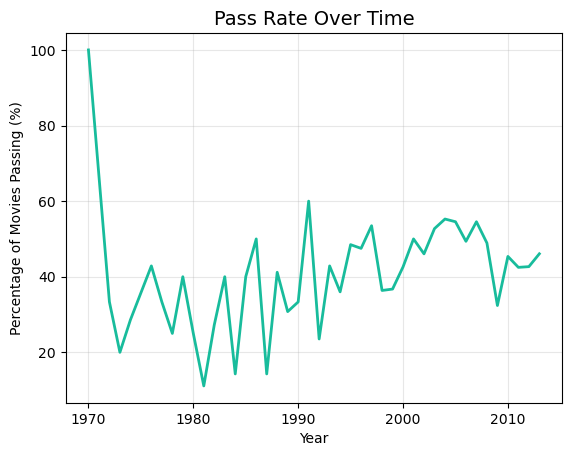

In [23]:
trend_df = movies_clean.groupby('year')['binary'].value_counts(normalize=True).unstack().reset_index()
trend_df['pass_percentage'] = trend_df['PASS'] * 100

sns.lineplot(data=trend_df, x='year', y='pass_percentage', color='#18bc9c', linewidth=2)
plt.title('Pass Rate Over Time', fontsize=14)
plt.ylabel('Percentage of Movies Passing (%)')
plt.xlabel('Year')
plt.grid(alpha=0.3)

<positron-console-cell-25>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Text(0, 0.5, 'Genre')

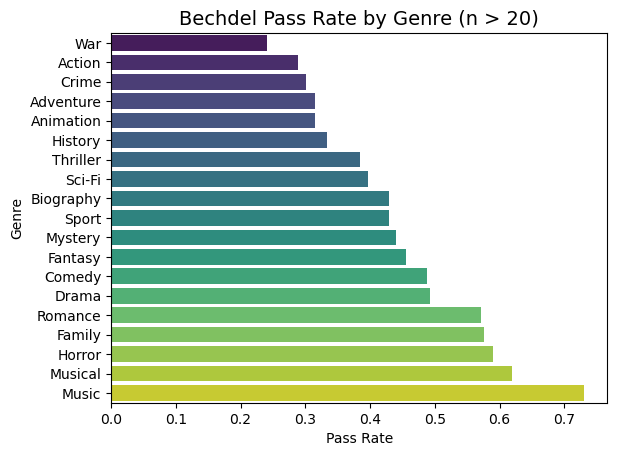

In [ ]:
genre_df = movies_clean.dropna(subset=['genre', 'binary']).copy()
genre_df['genre'] = genre_df['genre'].str.split(', ')
genre_exploded = genre_df.explode('genre')

genre_stats = genre_exploded.groupby('genre')['binary'].value_counts(normalize=True).unstack().reset_index()
genre_counts = genre_exploded['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

genre_analysis = pd.merge(genre_stats, genre_counts, on='genre')
genre_analysis = genre_analysis[genre_analysis['count'] > 20].sort_values('PASS', ascending=True)

sns.barplot(data=genre_analysis, y='genre', x='PASS', palette='viridis')
plt.title('Bechdel Pass Rate by Genre (n > 20)', fontsize=14)
plt.xlabel('Pass Rate')
plt.ylabel('Genre')

In [9]:
cat_cols = ['rated', 'language', 'country', 'genre']

numeric_features = ['year', 'budget_2013', 'domgross_2013', 'intgross_2013', 'metascore', 'imdb_rating', 'runtime', 'imdb_votes']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, cat_cols)
    ]
)

rfc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=4025))
])

In [10]:
X = movies_clean[cat_cols + numeric_features]
y = movies_clean['binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4025)

rfc_pipeline.fit(X_train, y_train)

accuracy = rfc_pipeline.score(X_test, y_test)
print(f"Pipeline Accuracy: {accuracy:.4f}")

y_pred = rfc_pipeline.predict(X_test)

Pipeline Accuracy: 0.6364


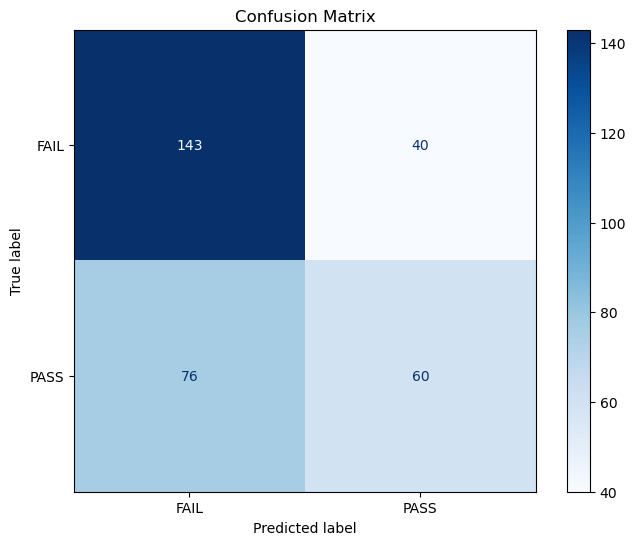


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        FAIL       0.65      0.78      0.71       183
        PASS       0.60      0.44      0.51       136

    accuracy                           0.64       319
   macro avg       0.63      0.61      0.61       319
weighted avg       0.63      0.64      0.62       319



In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['FAIL', 'PASS'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['FAIL', 'PASS']))